In [1]:
print ("hsh")

hsh


In [3]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate mock data components
num_rows = 200
dates = pd.date_range(start='2025-01-01', periods=num_rows).strftime('%Y-%m-%d')
products = ['Laptop', 'Smartphone', 'Headphones', 'T-Shirt', 'Blender', 'Novel']
categories = ['Electronics', 'Electronics', 'Electronics', 'Clothing', 'Home & Kitchen', 'Books']

prod_cat_map = dict(zip(products, categories))
chosen_products = np.random.choice(products, num_rows)
chosen_categories = [prod_cat_map[p] for p in chosen_products]

prices = np.random.uniform(10, 500, num_rows).round(2)
quantities = np.random.randint(1, 20, num_rows)
total_sales = (prices * quantities).round(2)

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Product': chosen_products,
    'Category': chosen_categories,
    'Price': prices,
    'Quantity Sold': quantities,
    'Total Sales': total_sales
})

# Introduce a few missing/invalid entries for validation testing
df.loc[15, 'Price'] = np.nan            # Missing value
df.loc[30, 'Quantity Sold'] = -5       # Invalid value
df.loc[45, 'Product'] = ""             # Missing value

# Save to CSV
df.to_csv('retail_sales.csv', index=False)
print("Successfully generated 'retail_sales.csv'.")

Successfully generated 'retail_sales.csv'.


In [9]:
df=pd.read_csv('retail_sales.csv')
df.head()

,Date,Product,Category,Price,Quantity Sold,Total Sales
0,2025-01-01,T-Shirt,Clothing,117.19,14,1640.66
1,2025-01-02,Blender,Home & Kitchen,283.47,5,1417.35
2,2025-01-03,Headphones,Electronics,207.88,12,2494.56
3,2025-01-04,Blender,Home & Kitchen,41.80,16,668.80
4,2025-01-05,Blender,Home & Kitchen,134.42,16,2150.72


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    str    
 1   Product        199 non-null    str    
 2   Category       200 non-null    str    
 3   Price          199 non-null    float64
 4   Quantity Sold  200 non-null    int64  
 5   Total Sales    200 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB


In [14]:
df.describe()

,Price,Quantity Sold,Total Sales
count,199.000000,200.000000,200.000000
mean,251.673266,10.045000,2548.186800
std,141.458708,5.588302,2215.734104
min,12.540000,-5.000000,87.780000
25%,133.670000,5.000000,737.355000
50%,240.270000,10.000000,1888.520000
75%,361.705000,15.000000,3542.480000
max,498.890000,19.000000,8966.880000


In [15]:
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    str    
 1   Product        199 non-null    str    
 2   Category       200 non-null    str    
 3   Price          199 non-null    float64
 4   Quantity Sold  200 non-null    int64  
 5   Total Sales    200 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB
None
Date             0
Product          1
Category         0
Price            1
Quantity Sold    0
Total Sales      0
dtype: int64
0


In [29]:

# df["Product"] = df["Product"].str.strip()
# df["Category"] = df["Category"].str.strip()


In [30]:
# df = df.replace(r"^\s*$", np.nan, regex=True)

In [31]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

In [32]:
# # df["Quantity Sold"] = df["Quantity Sold"].fillna(
# #     df["Quantity Sold"].median()
# )

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           0 non-null      datetime64[us]
 1   Product        199 non-null    str           
 2   Category       200 non-null    str           
 3   Price          199 non-null    float64       
 4   Quantity Sold  200 non-null    int64         
 5   Total Sales    200 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 9.5 KB


In [35]:
import pandas as pd

df = pd.read_csv("retail_sales.csv")


print(df.info())


print("\nMissing values:")
print(df.isnull().sum())


print("\nDuplicate rows:")
print(df.duplicated().sum())


print("\nUnique values:")
print(df.nunique())


print("\nData types:")
print(df.dtypes)


print("\nStatistics:")
print(df.describe())


print("\nFirst 5 rows:")
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    str    
 1   Product        199 non-null    str    
 2   Category       200 non-null    str    
 3   Price          199 non-null    float64
 4   Quantity Sold  200 non-null    int64  
 5   Total Sales    200 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB
None

Missing values:
Date             0
Product          1
Category         0
Price            1
Quantity Sold    0
Total Sales      0
dtype: int64

Duplicate rows:
0

Unique values:
Date             200
Product            6
Category           4
Price            198
Quantity Sold     20
Total Sales      199
dtype: int64

Data types:
Date                 str
Product              str
Category             str
Price            float64
Quantity Sold      int64
Total Sales      float64
dtype: obje

In [37]:
df['Product'] = df['Product'].fillna(df['Product'].mode()[0])


In [38]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [39]:
df.isnull().sum()

Date             0
Product          0
Category         0
Price            0
Quantity Sold    0
Total Sales      0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df = df.drop_duplicates()

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df['Date'] = pd.to_datetime(df['Date'])

In [44]:
df.dtypes

Date             datetime64[us]
Product                     str
Category                    str
Price                   float64
Quantity Sold             int64
Total Sales             float64
dtype: object

In [45]:
df['Sales Percentage'] = (
    df['Total Sales'] / df['Total Sales'].sum()
) * 100

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           200 non-null    str    
 1   Product        199 non-null    str    
 2   Category       200 non-null    str    
 3   Price          199 non-null    float64
 4   Quantity Sold  200 non-null    int64  
 5   Total Sales    200 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB


In [ ]:

import pandas as pd
import numpy as np


df = pd.read_csv("retail_sales.csv")


print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


print("\nDuplicate rows:", df.duplicated().sum())

# 4. Missing values check
print("\nMissing values:")
print(df.isnull().sum())


df = df.drop_duplicates()


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()


if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")


numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


print("\nNegative values:")
print((df[numeric_columns] < 0).sum())


print("\nMissing values after cleaning:")
print(df.isnull().sum())


print("\nStatistics:")
print(df.describe())


print("\nFinal Shape:", df.shape)


df.to_csv("retail_sales_cleaned.csv", index=False)

print("\nCleaned file saved successfully!")

Shape: (200, 6)

Columns:
Index(['Date', 'Product', 'Category', 'Price', 'Quantity Sold', 'Total Sales'], dtype='str')

First 5 rows:
         Date     Product        Category   Price  Quantity Sold  Total Sales
0  2025-01-01     T-Shirt        Clothing  117.19             14      1640.66
1  2025-01-02     Blender  Home & Kitchen  283.47              5      1417.35
2  2025-01-03  Headphones     Electronics  207.88             12      2494.56
3  2025-01-04     Blender  Home & Kitchen   41.80             16       668.80
4  2025-01-05     Blender  Home & Kitchen  134.42             16      2150.72

Duplicate rows: 0

Missing values:
Date             0
Product          1
Category         0
Price            1
Quantity Sold    0
Total Sales      0
dtype: int64

Negative values:
price            0
quantity_sold    1
total_sales      0
dtype: int64

Missing values after cleaning:
date             0
product          1
category         0
price            1
quantity_sold    0
total_sales      0
d

C:\Users\Hitesh\AppData\Local\Temp\ipykernel_25992\588016110.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [56]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)
print(df.head())

(200, 6)
date             0
product          1
category         0
price            1
quantity_sold    0
total_sales      0
dtype: int64
0
date             datetime64[us]
product                     str
category                    str
price                   float64
quantity_sold             int64
total_sales             float64
dtype: object
        date     product        category   price  quantity_sold  total_sales
0 2025-01-01     T-Shirt        Clothing  117.19             14      1640.66
1 2025-01-02     Blender  Home & Kitchen  283.47              5      1417.35
2 2025-01-03  Headphones     Electronics  207.88             12      2494.56
3 2025-01-04     Blender  Home & Kitchen   41.80             16       668.80
4 2025-01-05     Blender  Home & Kitchen  134.42             16      2150.72


In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv("retail_sales.csv")


df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


print(df.columns.tolist())


df["date"] = pd.to_datetime(df["date"], errors="coerce")


df["product"] = df["product"].fillna(df["product"].mode()[0])


df["price"] = df["price"].fillna(df["price"].median())


df = df.drop_duplicates()


print("\nMissing values:")
print(df.isnull().sum())


print("\nData types:")
print(df.dtypes)

print("\nShape:", df.shape)


print("\nFirst 5 rows:")
print(df.head())

['date', 'product', 'category', 'price', 'quantity_sold', 'total_sales']

Missing values:
date             0
product          0
category         0
price            0
quantity_sold    0
total_sales      0
dtype: int64

Data types:
date             datetime64[us]
product                     str
category                    str
price                   float64
quantity_sold             int64
total_sales             float64
dtype: object

Shape: (200, 6)

First 5 rows:
        date     product        category   price  quantity_sold  total_sales
0 2025-01-01     T-Shirt        Clothing  117.19             14      1640.66
1 2025-01-02     Blender  Home & Kitchen  283.47              5      1417.35
2 2025-01-03  Headphones     Electronics  207.88             12      2494.56
3 2025-01-04     Blender  Home & Kitchen   41.80             16       668.80
4 2025-01-05     Blender  Home & Kitchen  134.42             16      2150.72


In [68]:
print(df.columns.tolist())
print(df.head())

['Date', 'Product', 'Category', 'Price', 'Quantity Sold', 'Total Sales']
         Date     Product        Category   Price  Quantity Sold  Total Sales
0  2025-01-01     T-Shirt        Clothing  117.19             14      1640.66
1  2025-01-02     Blender  Home & Kitchen  283.47              5      1417.35
2  2025-01-03  Headphones     Electronics  207.88             12      2494.56
3  2025-01-04     Blender  Home & Kitchen   41.80             16       668.80
4  2025-01-05     Blender  Home & Kitchen  134.42             16      2150.72


Your columns are:
['Date', 'Product', 'Category', 'Price', 'Quantity Sold', 'Total Sales']

Numeric columns:
['Price', 'Quantity Sold', 'Total Sales']


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_25992\1533292555.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


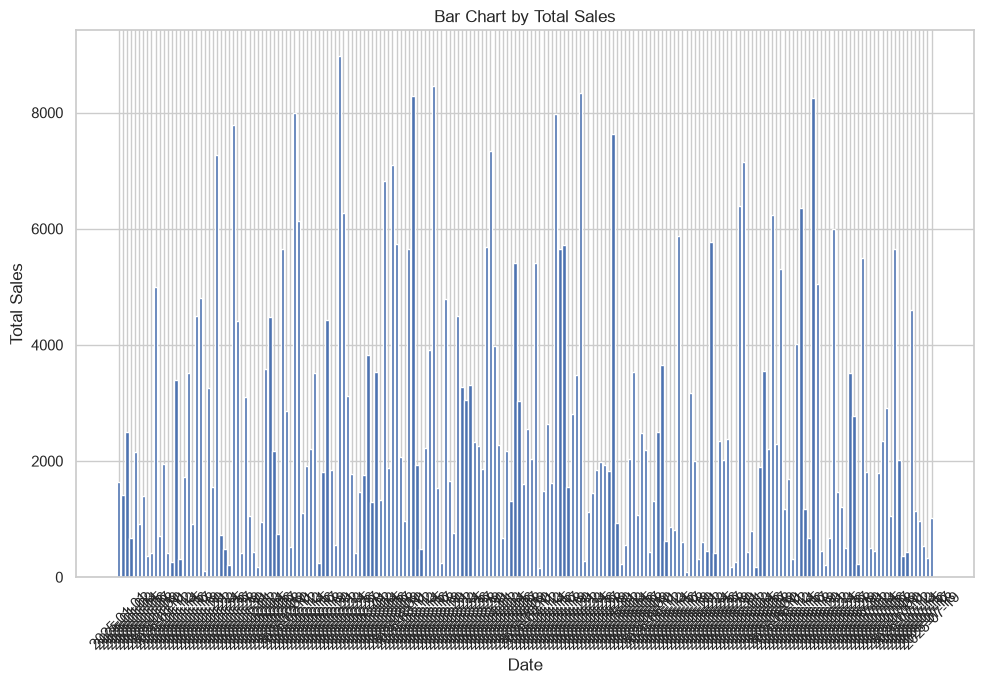

In [85]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("retail_sales.csv")


df.columns = df.columns.str.strip()


print("Your columns are:")
print(df.columns.tolist())


numeric_cols = df.select_dtypes(include="number").columns

print("\nNumeric columns:")
print(numeric_cols.tolist())


sales_col = numeric_cols[-1]

text_cols = df.select_dtypes(include="object").columns
category_col = text_cols[0]


sales = df.groupby(category_col)[sales_col].sum()


plt.figure(figsize=(10, 7))
plt.bar(sales.index.astype(str), sales.values)

plt.title("Bar Chart by Total Sales")
plt.xlabel(category_col)
plt.ylabel(sales_col)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
print(df.columns)

Index(['Date', 'Product', 'Category', 'Price', 'Quantity Sold', 'Total Sales'], dtype='str')


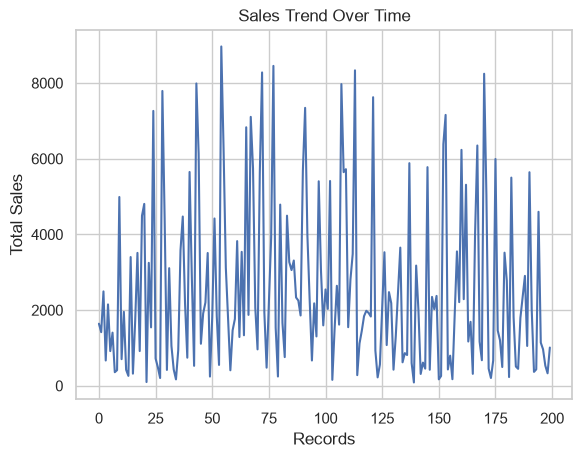

In [88]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Total Sales'])
plt.xlabel("Records")
plt.ylabel("Total Sales")
plt.title("Sales Trend Over Time")
plt.show()

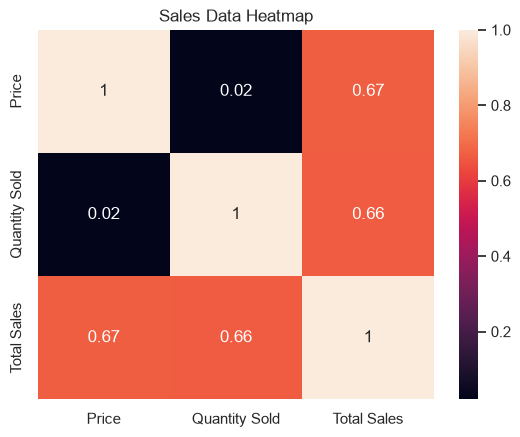

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Sales Data Heatmap")
plt.show()